In [2]:
import os, ujson as json, numpy as np
from matplotlib import pyplot as plt

experiments = sorted([exp for exp in os.listdir("experiments")])
print(len(experiments))
necessary_files = ["args.json", "logs.jsonl", "unique_answers.jsonl"]

exp_results = []
for exp in experiments:
    if any(not os.path.exists(f"experiments/{exp}/{f}") for f in necessary_files):
        continue

    with open(f"experiments/{exp}/args.json", "r") as f:
        exp_args = json.load(f)

    learning_rate = exp_args["learning_rate"]
    
    experiment_type = ""
    sample_strategy = exp_args.get("sample_strategy", "iid")
    if sample_strategy == "tree":
        experiment_type = f"tree-{exp_args['tree_depth']}-{exp_args['tree_degree']}"
    else:
        if "group_size" not in exp_args:
            continue
        experiment_type = f"iid-{exp_args['group_size']}"

    exp_logs = []
    with open(f"experiments/{exp}/logs.jsonl", "r") as f:
        for line in f:
            exp_logs.append(json.loads(line))

    task_id = exp_args["task_id"]

    with open(f"experiments/{exp}/unique_answers.jsonl", "r") as f:
        unique_answers = [json.loads(line) for line in f]

    already_seen_answers = set()
    num_new_answers = []
    for answers in unique_answers:
        this_answers = set(answers)
        new_answers = this_answers - already_seen_answers
        num_new_answers.append(len(new_answers))
        already_seen_answers |= this_answers

    # mean_train_score = [log["mean_train_score"] for log in exp_logs]
    mean_eval_score = [log["mean_eval_score"] for log in exp_logs]
    uniqueness = [log["uniqueness"]/100.0 for log in exp_logs]

    correct_logprobs = [np.mean(log["correct_logprobs"]) for log in exp_logs]
    incorrect_logprobs = [np.mean(log["incorrect_logprobs"]) for log in exp_logs]
    num_unique_correct_answers = [log["num_unique_correct_answers"] for log in exp_logs]

    is_success = mean_eval_score[-1] >= 0.99

    exp_results.append({"task_id": task_id, "mean_eval_score": mean_eval_score, "uniqueness": uniqueness, "learning_rate": learning_rate, "experiment_type": experiment_type, "correct_logprobs": correct_logprobs, "incorrect_logprobs": incorrect_logprobs, "num_unique_correct_answers": num_unique_correct_answers, "num_new_answers": num_new_answers, "is_success": is_success})
    # plot these things on a row with 3 columns: (1) (mean_eval_score and uniqueness), (2) (correct_logprobs and incorrect_logprobs), (3) (num_unique_correct_answers)

    iterations = list(range(len(mean_eval_score)))

print(f"Matching number of experiments: {len(exp_results)}")

487


/home/plaban/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/plaban/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Matching number of experiments: 460


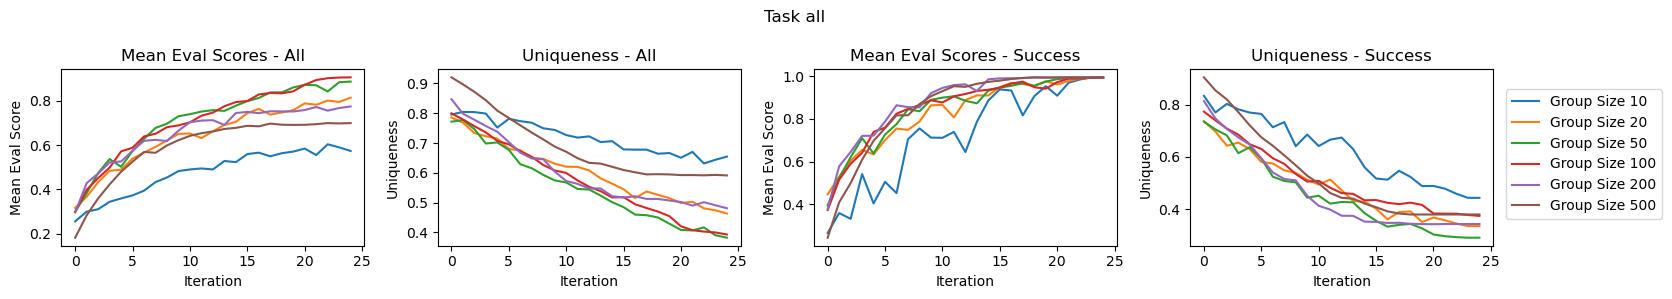

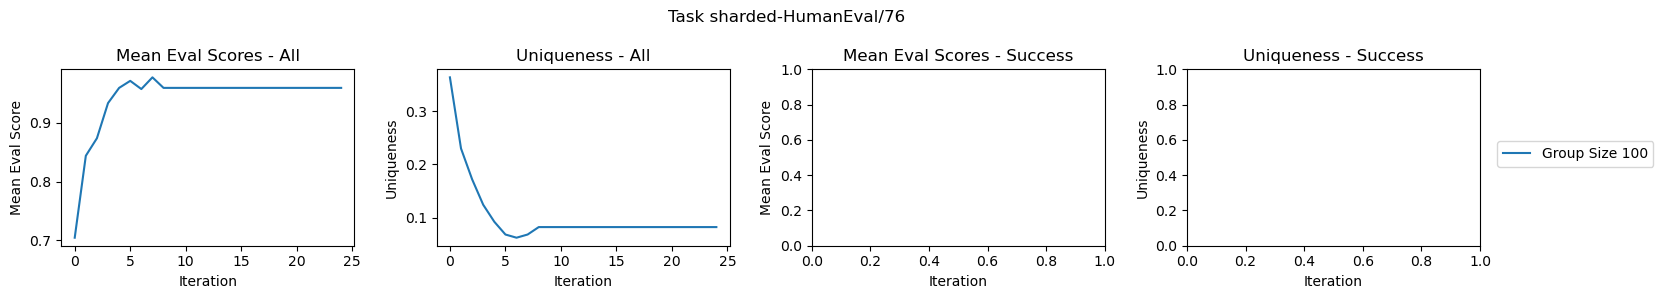

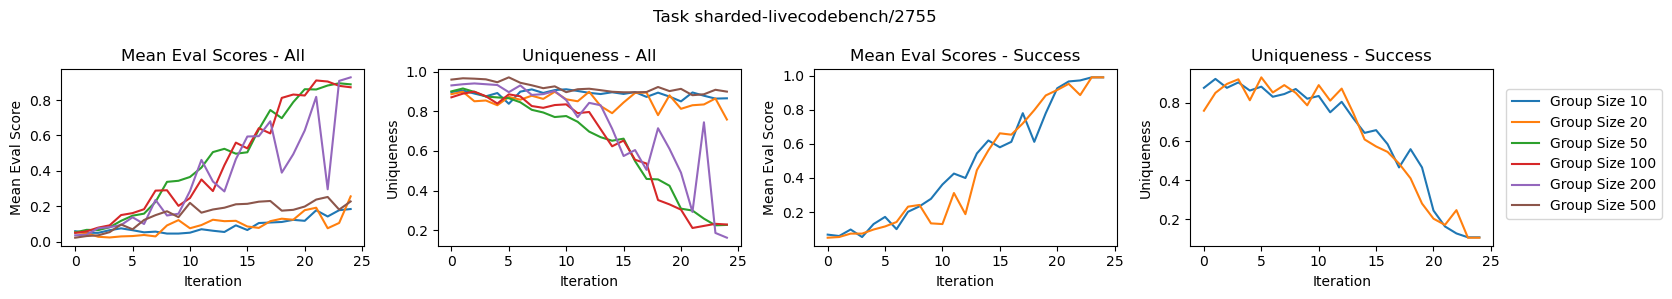

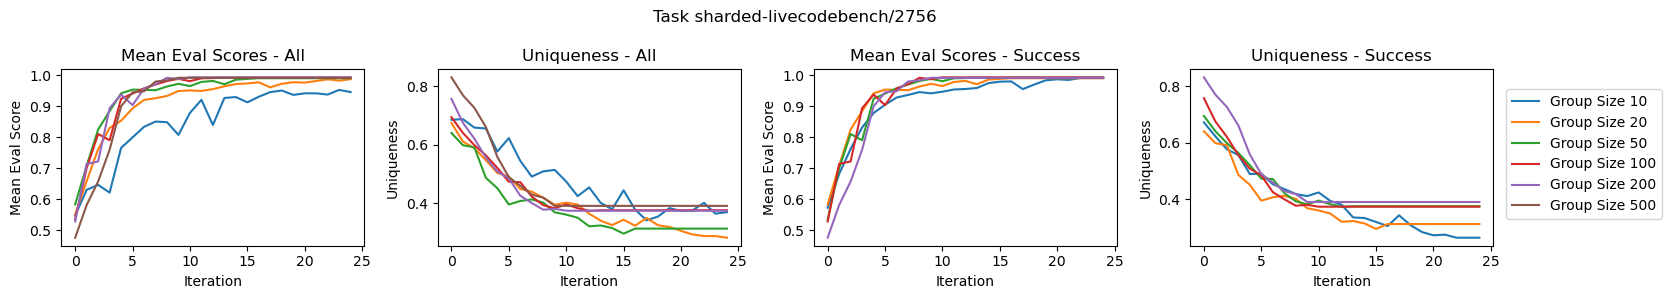

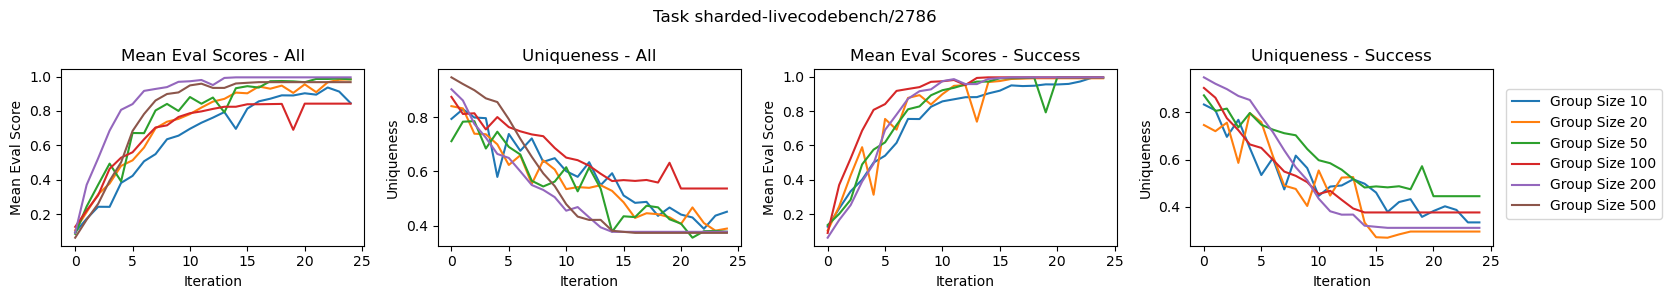

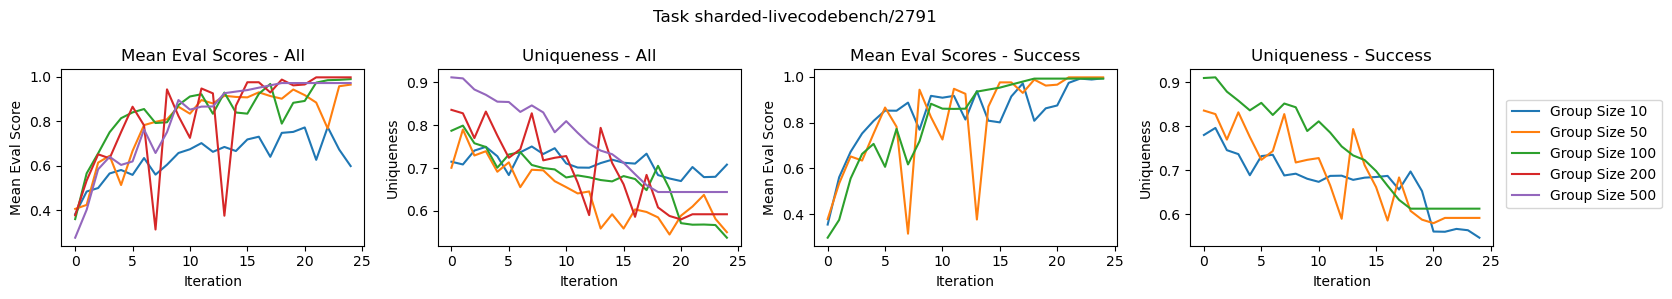

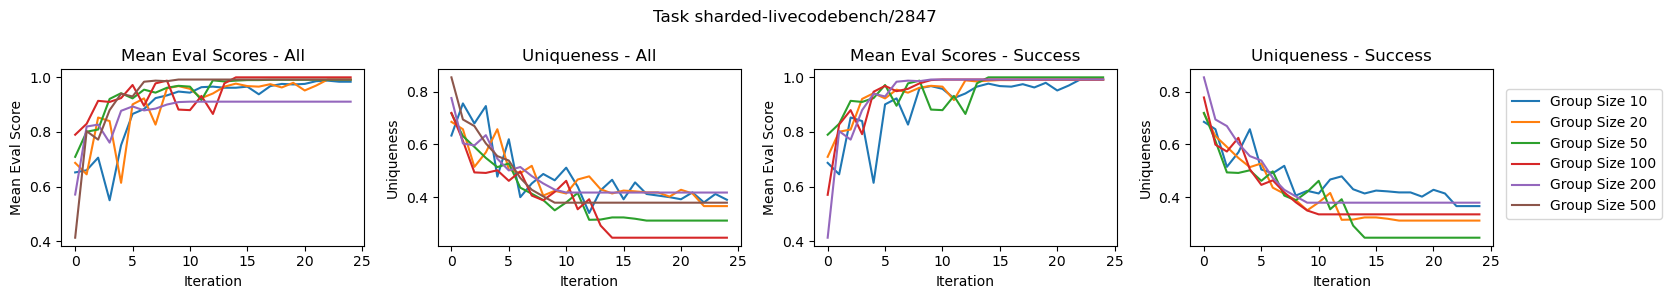

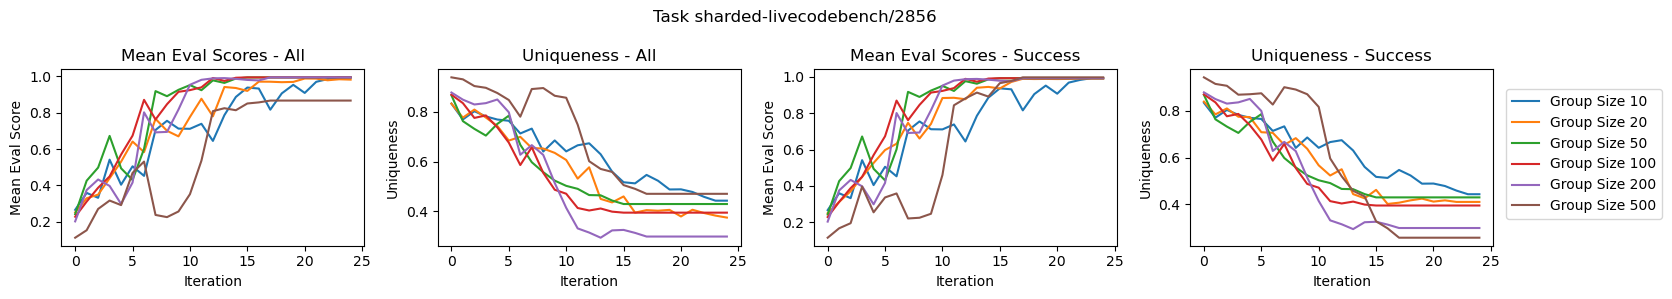

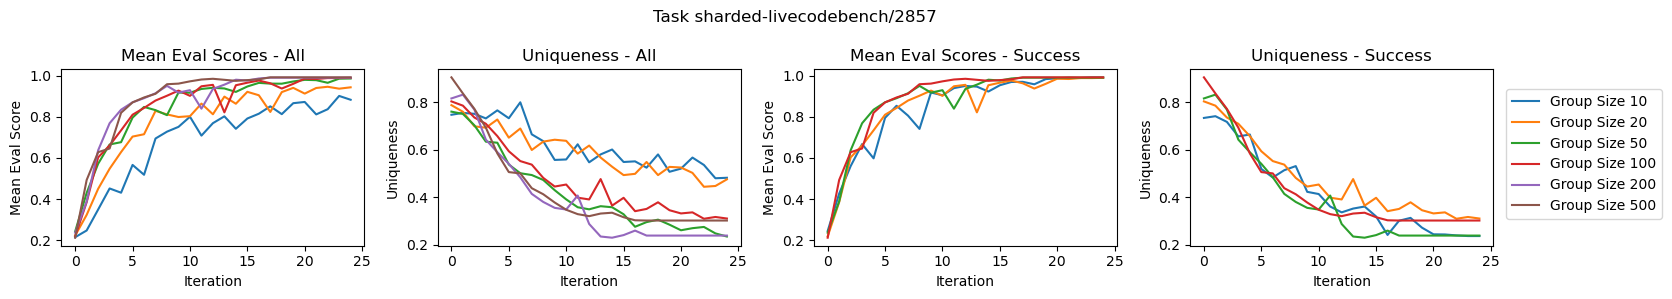

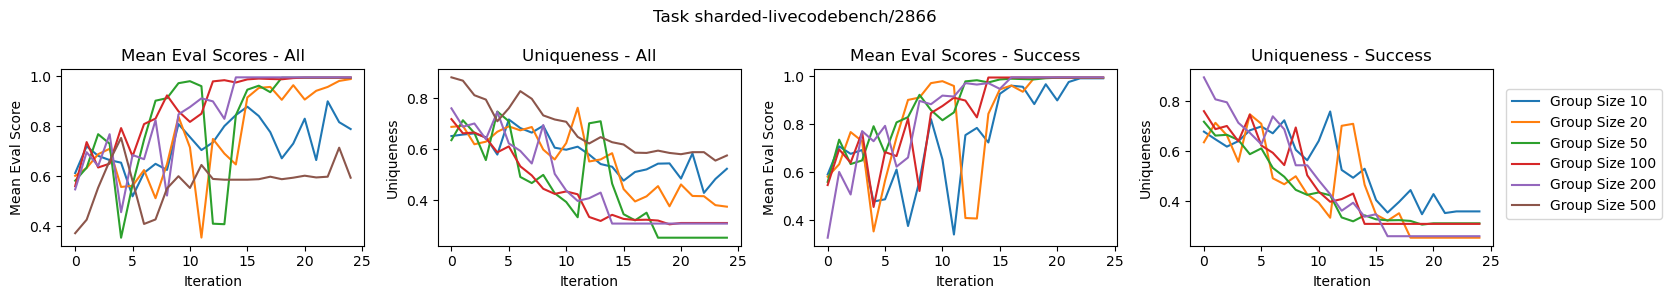

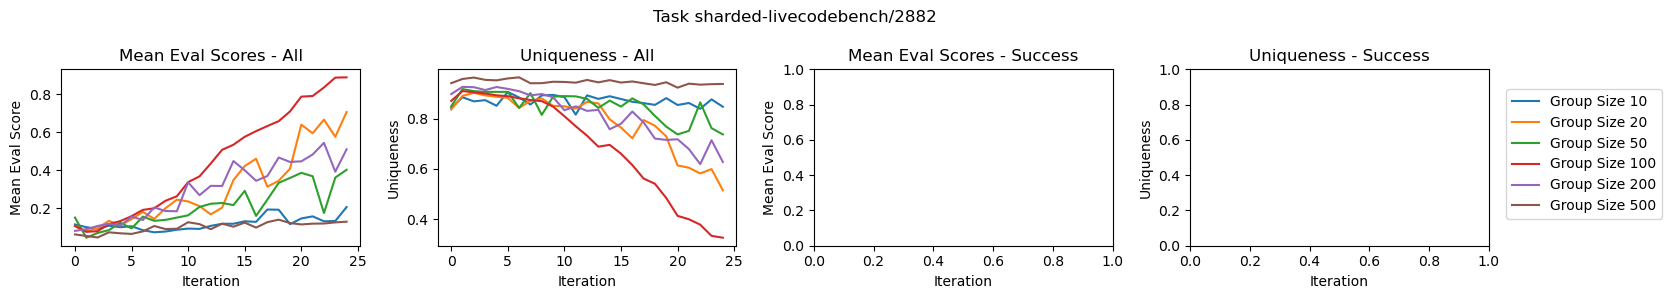

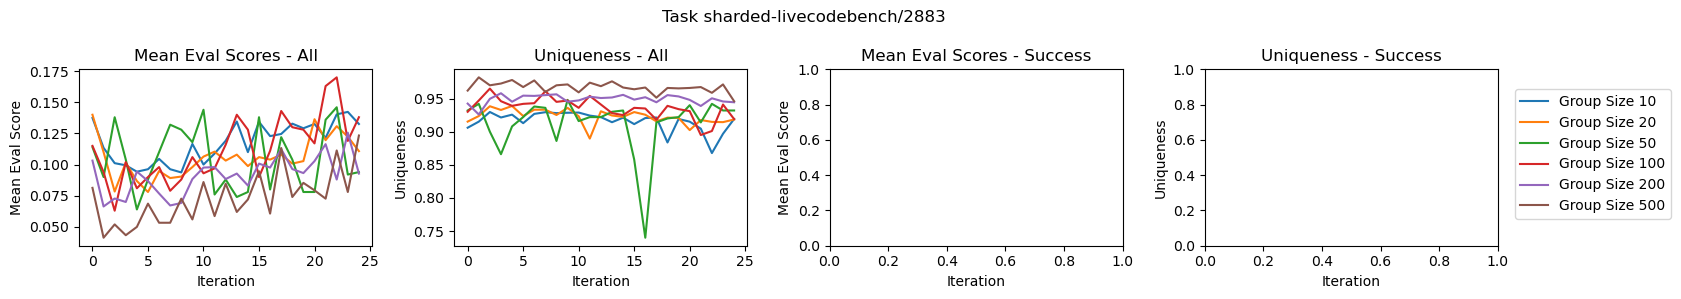

In [ ]:
from matplotlib import pyplot as plt
import numpy as np

experiment_types = sorted(list(set([res["experiment_type"] for res in exp_results])))
task_ids = sorted(list(set([res["task_id"] for res in exp_results])))

max_iter = 25
for task_id in ["all"] + task_ids:
    fig, axes = plt.subplots(1, 4, figsize=(16, 3))
    handles, labels = None, None
    
    for plot_idx, plot_type in enumerate(["all", "success"]):
        all_mean_eval_scores, all_uniquenesses = {}, {}
        for experiment_type in experiment_types:
            all_mean_eval_scores[experiment_type], all_uniquenesses[experiment_type] = [], []
            this_results = [res for res in exp_results if (res["task_id"] == task_id or task_id == "all") and res["experiment_type"] == experiment_type]
            if plot_type == "success":
                this_results = [res for res in this_results if res["is_success"]]

            for res in this_results:
                mean_eval_score = res["mean_eval_score"][:max_iter]
                if len(mean_eval_score) < max_iter:
                    mean_eval_score += [mean_eval_score[-1]] * (max_iter - len(mean_eval_score))
                
                uniqueness = res["uniqueness"][:max_iter]
                if len(uniqueness) < max_iter:
                    uniqueness += [uniqueness[-1]] * (max_iter - len(uniqueness))

                all_mean_eval_scores[experiment_type].append(mean_eval_score)
                all_uniquenesses[experiment_type].append(uniqueness)
        
        ax_offset = plot_idx * 2
        for experiment_type in experiment_types:
            if len(all_mean_eval_scores[experiment_type]) > 0:
                mean_eval_scores = np.mean(all_mean_eval_scores[experiment_type], axis=0)
                uniquenesses = np.mean(all_uniquenesses[experiment_type], axis=0)
                axes[ax_offset].plot(mean_eval_scores, label=f"{experiment_type}")
                axes[ax_offset + 1].plot(uniquenesses, label=f"{experiment_type}")
        
        if handles is None:
            handles, labels = axes[ax_offset].get_legend_handles_labels()
        
        axes[ax_offset].set_title(f"Mean Eval Scores - {plot_type.capitalize()}")
        axes[ax_offset].set_xlabel("Iteration")
        axes[ax_offset].set_ylabel("Mean Eval Score")
        
        axes[ax_offset + 1].set_title(f"Uniqueness - {plot_type.capitalize()}")
        axes[ax_offset + 1].set_xlabel("Iteration")
        axes[ax_offset + 1].set_ylabel("Uniqueness")
    
    plt.suptitle(f"Task {task_id}")
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.94, 0.5))
    plt.tight_layout(rect=[0, 0, 0.95, 1])
    plt.show()


In [3]:
num_plots = len(exp_results)
num_cols = 8
num_rows = (num_plots + num_cols - 1) // num_cols  # Ceiling division

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 5 * num_rows))

if num_rows == 1:
    axes = axes.reshape(1, -1)
axes_flat = axes.flatten()

for idx, result in enumerate(exp_results):
    ax = axes_flat[idx]
    ax.plot(result["mean_eval_score"], label="Mean Eval Score")
    ax.plot(result["uniqueness"], label="Uniqueness")
    ax.set_ylim(0, 1)
    ax.legend()
    ax.set_title(f"Task {result['task_id']}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Score")

for idx in range(num_plots, len(axes_flat)):
    axes_flat[idx].axis('off')

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [1]:
# Group data by experiment type and collect all (uniqueness, mean_eval_score) pairs
from collections import defaultdict

experiment_type_data = defaultdict(lambda: {"uniqueness": [], "mean_eval_score": []})

for result in exp_results:
    experiment_type = result["experiment_type"]
    # Collect all points from all iterations
    for u, score in zip(result["uniqueness"], result["mean_eval_score"]):
        experiment_type_data[experiment_type]["uniqueness"].append(u)
        experiment_type_data[experiment_type]["mean_eval_score"].append(score)

# Create scatter plots, one for each experiment type
experiment_types = sorted(experiment_type_data.keys())
num_experiment_types = len(experiment_types)
num_cols = min(4, num_experiment_types)
num_rows = (num_experiment_types + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))

# Handle single plot case
if num_experiment_types == 1:
    axes = [axes]
else:
    axes = axes.flatten() if num_experiment_types > 1 else [axes]

# Plot scatter for each experiment type
for idx, experiment_type in enumerate(experiment_types):
    ax = axes[idx] if num_experiment_types > 1 else axes[0]
    data = experiment_type_data[experiment_type]
    ax.scatter(data["uniqueness"], data["mean_eval_score"], alpha=0.5, s=10)
    ax.set_xlabel("Uniqueness")
    ax.set_ylabel("Mean Eval Score")
    ax.set_title(f"{experiment_type}")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

# Hide unused subplots
if num_experiment_types > 1:
    for idx in range(num_experiment_types, len(axes)):
        axes[idx].axis('off')

plt.tight_layout()
plt.show()


NameError: name 'exp_results' is not defined